In [1]:
# ============================================================
# QBiLSTM-Q on MPQA with Multiple Qubit Configurations (2, 4, 6, 8)
# Using specified quantum circuit with variable qubits
# ============================================================

!pip install pennylane datasets -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
import time, random, re, warnings
import nltk
import pennylane as qml
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ============================================================
# QUBITS CONFIGURATION
# ============================================================

QUBIT_CONFIGS = [2, 4, 6, 8]
FIXED_SEED = 42  # Fixed seed for fair comparison

# ============================================================
# DATA PREPROCESSING (Will be done once)
# ============================================================

def preprocess_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.lower()
    return text.strip()

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r'[^\w\s]', ' ', statement)
    statement = re.sub(r'\d+', '', statement)
    words = statement.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print("\nLoading MPQA dataset...")
ds = load_dataset("jxm/mpqa")
df = ds["train"].to_pandas()

# Clean text
df['cleaned_text'] = df['sentence'].apply(preprocess_text)
df = df[df['cleaned_text'] != '[deleted]']
df = df[df['cleaned_text'] != '[removed]']
df['cleaned_text'] = df['cleaned_text'].apply(clean_statement)
df = df[df['cleaned_text'].str.len() > 3]

# Label encoding
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])
print(f"Classes: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

# Use class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(df['label']), y=df['label'])
class_weight_dict = dict(zip(np.unique(df['label']), class_weights))
print(f"Class weights: {class_weight_dict}")

# Tokenization
MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128

tokens = tokenizer(
    df['cleaned_text'].tolist(),
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

input_ids = tokens['input_ids']
attention_masks = tokens['attention_mask']
labels = torch.tensor(df['label'].values)

# Get model hidden size
temp_model = AutoModel.from_pretrained(MODEL_NAME)
HIDDEN_SIZE = temp_model.config.hidden_size
print(f"Model hidden size: {HIDDEN_SIZE}")
del temp_model

# Fixed train/val split for fair comparison
random.seed(FIXED_SEED)
np.random.seed(FIXED_SEED)
torch.manual_seed(FIXED_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(FIXED_SEED)

train_inputs, val_inputs, train_labels, val_labels = train_test_split(
    input_ids, labels, test_size=0.2, random_state=FIXED_SEED, stratify=labels
)
train_masks, val_masks, _, _ = train_test_split(
    attention_masks, labels, test_size=0.2, random_state=FIXED_SEED, stratify=labels
)

print(f"Train size: {len(train_inputs)}, Val size: {len(val_inputs)}")

# ============================================================
# QUANTUM CIRCUIT FACTORY (Creates circuits with different qubits)
# ============================================================

def create_quantum_circuit(n_qubits):
    """Create a quantum circuit with specified number of qubits"""
    dev = qml.device("default.qubit", wires=n_qubits)
    
    @qml.qnode(dev, interface='torch')
    def quantum_circuit(weights, inputs):
        # Apply Hadamard gates to all qubits
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
        
        # Encode inputs (pad if necessary)
        for i in range(min(n_qubits, len(inputs))):
            if i % 2 == 0:
                qml.RX(inputs[i], wires=i)
            else:
                qml.RY(inputs[i], wires=i)
        
        # Entanglement layer (ring topology)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])
        
        # Apply trainable rotations
        for i in range(n_qubits):
            qml.RZ(weights[i], wires=i)
        
        # Second entanglement layer for better information flow
        for i in range(0, n_qubits-1, 2):
            qml.CZ(wires=[i, i+1])
        
        # Measure all qubits
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    
    return quantum_circuit

# ============================================================
# MODEL DEFINITION (Dynamic qubits)
# ============================================================

class QBiLSTM(nn.Module):
    def __init__(self, num_classes=2, hidden_size=1024, n_qubits=2, dropout_rate=0.3):
        super(QBiLSTM, self).__init__()
        
        self.n_qubits = n_qubits
        self.quantum_circuit = create_quantum_circuit(n_qubits)
        
        self.bert = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
        
        for param in self.bert.parameters():
            param.requires_grad = True
        
        self.feature_extractor = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU()
        )
        
        self.bilstm = nn.LSTM(
            input_size=256,
            hidden_size=128,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_rate,
            num_layers=2
        )
        self.lstm_norm = nn.LayerNorm(256)
        
        # Quantum projection (project to n_qubits features)
        self.quantum_proj = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, n_qubits),
            nn.Tanh()
        )
        
        # Quantum weights (one parameter per qubit)
        self.quantum_weights = nn.Parameter(torch.randn(n_qubits, dtype=torch.float32) * 0.01)
        
        # Quantum feature expander
        self.quantum_expander = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.GELU(),
            nn.Linear(128, 64)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def quantum_layer(self, features):
        batch_size = features.shape[0]
        quantum_outputs = []
        
        for i in range(batch_size):
            q_input = features[i].detach().cpu().numpy()
            weights = self.quantum_weights.detach().cpu().numpy()
            
            try:
                q_out = self.quantum_circuit(weights, q_input)
                q_out_tensor = torch.tensor(q_out, dtype=torch.float32).to(features.device)
                q_out_tensor = q_out_tensor * 2.0  # Scale for better gradient flow
            except Exception as e:
                q_out_tensor = torch.zeros(self.n_qubits, device=features.device)
            
            quantum_outputs.append(q_out_tensor)
        
        quantum_outputs = torch.stack(quantum_outputs)
        quantum_outputs = self.quantum_expander(quantum_outputs)
        
        return quantum_outputs
    
    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.long()
        attention_mask = attention_mask.float()
        
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = bert_out.last_hidden_state.float()
        
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size())
        sum_embeddings = torch.sum(last_hidden * mask_expanded, dim=1)
        sum_mask = torch.sum(mask_expanded, dim=1)
        bert_pooled = sum_embeddings / (sum_mask + 1e-9)
        
        features = self.feature_extractor(bert_pooled)
        
        features_seq = features.unsqueeze(1)
        lstm_out, _ = self.bilstm(features_seq)
        lstm_features = lstm_out[:, -1, :]
        lstm_features = self.lstm_norm(lstm_features)
        
        quantum_input = self.quantum_proj(lstm_features)
        quantum_out = self.quantum_layer(quantum_input)
        
        combined = torch.cat([lstm_features, quantum_out], dim=1)
        output = self.classifier(combined)
        
        return output

# ============================================================
# TRAINING FUNCTION FOR A SPECIFIC QUBIT CONFIGURATION
# ============================================================

def train_for_qubits(n_qubits, learning_rate=2e-5, batch_size=32, epochs=10):
    print(f"\n{'='*80}")
    print(f"TRAINING WITH {n_qubits}-QUBIT QUANTUM CIRCUIT")
    print(f"Learning Rate: {learning_rate}, Batch Size: {batch_size}, Epochs: {epochs}")
    print(f"{'='*80}")
    
    # Create dataloaders
    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model with specified qubits
    model = QBiLSTM(num_classes=2, hidden_size=HIDDEN_SIZE, n_qubits=n_qubits).to(device)
    
    # Class weights tensor
    class_weights_tensor = torch.tensor([class_weight_dict[0], class_weight_dict[1]], dtype=torch.float32).to(device)
    
    # Optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    
    # Track metrics
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0
    best_f1 = 0
    best_precision = 0
    best_recall = 0
    best_val_loss = 0
    final_train_acc = 0
    best_confusion_matrix = None
    best_predictions = None
    best_true_labels = None
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        total_train_loss = 0
        train_preds = []
        train_labels_list = []
        
        for batch in train_loader:
            b_input_ids, b_mask, b_labels = [b.to(device) for b in batch]
            
            optimizer.zero_grad()
            logits = model(b_input_ids, b_mask)
            loss = F.cross_entropy(logits, b_labels, weight=class_weights_tensor)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_list.extend(b_labels.cpu().numpy())
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_acc = accuracy_score(train_labels_list, train_preds)
        
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        # Validation
        model.eval()
        val_preds = []
        val_labels_list = []
        total_val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_mask, b_labels = [b.to(device) for b in batch]
                logits = model(b_input_ids, b_mask)
                loss = F.cross_entropy(logits, b_labels, weight=class_weights_tensor)
                total_val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(b_labels.cpu().numpy())
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)
        val_f1 = f1_score(val_labels_list, val_preds, average='weighted')
        val_precision = precision_score(val_labels_list, val_preds, average='weighted', zero_division=0)
        val_recall = recall_score(val_labels_list, val_preds, average='weighted', zero_division=0)
        
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_f1 = val_f1
            best_precision = val_precision
            best_recall = val_recall
            best_val_loss = avg_val_loss
            final_train_acc = train_acc
            best_confusion_matrix = confusion_matrix(val_labels_list, val_preds)
            best_predictions = val_preds
            best_true_labels = val_labels_list
    
    training_time = time.time() - start_time
    
    print(f"\n📊 Final Results for {n_qubits}-Qubit Circuit:")
    print(f"   Best Val Acc: {best_val_acc:.4f}")
    print(f"   F1-Score: {best_f1:.4f}")
    print(f"   Precision: {best_precision:.4f}")
    print(f"   Recall: {best_recall:.4f}")
    print(f"   Training Time: {training_time:.2f} seconds")
    
    return {
        'n_qubits': n_qubits,
        'best_val_accuracy': best_val_acc,
        'final_val_accuracy': val_accs[-1] if val_accs else best_val_acc,
        'final_train_accuracy': final_train_acc,
        'f1_score': best_f1,
        'precision': best_precision,
        'recall': best_recall,
        'val_loss': best_val_loss,
        'training_time': training_time,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accs,
        'val_accuracies': val_accs,
        'confusion_matrix': best_confusion_matrix,
        'predictions': best_predictions,
        'true_labels': best_true_labels
    }

# ============================================================
# RUN TRAINING FOR ALL QUBIT CONFIGURATIONS
# ============================================================

print("\n" + "="*80)
print("QBiLSTM-Q MODEL ON MPQA DATASET - MULTIPLE QUBIT CONFIGURATIONS")
print(f"Model: {MODEL_NAME} (hidden size={HIDDEN_SIZE})")
print(f"Qubit Configurations to test: {QUBIT_CONFIGS}")
print(f"Fixed Seed: {FIXED_SEED}")
print("="*80)

all_results = []

for n_qubits in QUBIT_CONFIGS:
    result = train_for_qubits(
        n_qubits=n_qubits,
        learning_rate=2e-5,
        batch_size=32,
        epochs=10
    )
    all_results.append(result)

# ============================================================
# STATISTICS ACROSS QUBIT CONFIGURATIONS
# ============================================================

metrics = ["best_val_accuracy", "final_val_accuracy", "final_train_accuracy",
           "f1_score", "precision", "recall", "training_time"]

stats = {}
for metric in metrics:
    values = [r[metric] for r in all_results]
    stats[metric] = {
        "mean": np.mean(values),
        "std":  np.std(values),
        "min":  np.min(values),
        "max":  np.max(values),
    }

stats_df = pd.DataFrame(stats).round(4)
print("\n" + "="*80)
print("STATISTICS ACROSS QUBIT CONFIGURATIONS")
print("="*80)
print(stats_df)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 56.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 110.2 MB/s eta 0:00:0000:0100:01


Device: cuda

Loading MPQA dataset...


README.md:   0%|          | 0.00/650 [00:00<?, ?B/s]

data/train-00000-of-00001-a7df005a1b0788(…):   0%|          | 0.00/141k [00:00<?, ?B/s]

data/test-00000-of-00001-05fc5ca1c399669(…):   0%|          | 0.00/33.7k [00:00<?, ?B/s]

...

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 | Train Loss: 0.6724 | Train Acc: 0.5873 | Val Loss: 0.4925 | Val Acc: 0.8457 | F1: 0.8468
Epoch 2/10 | Train Loss: 0.5167 | Train Acc: 0.8437 | Val Loss: 0.4326 | Val Acc: 0.8581 | F1: 0.8608
Epoch 3/10 | Train Loss: 0.4241 | Train Acc: 0.8693 | Val Loss: 0.4126 | Val Acc: 0.8705 | F1: 0.8723
Epoch 4/10 | Train Loss: 0.3822 | Train Acc: 0.8823 | Val Loss: 0.3985 | Val Acc: 0.8740 | F1: 0.8765
Epoch 5/10 | Train Loss: 0.3547 | Train Acc: 0.8919 | Val Loss: 0.3886 | Val Acc: 0.8723 | F1: 0.8746
Epoch 6/10 | Train Loss: 0.3352 | Train Acc: 0.9022 | Val Loss: 0.4242 | Val Acc: 0.8788 | F1: 0.8793
Epoch 7/10 | Train Loss: 0.3240 | Train Acc: 0.9099 | Val Loss: 0.4195 | Val Acc: 0.8699 | F1: 0.8728
Epoch 8/10 | Train Loss: 0.3140 | Train Acc: 0.9133 | Val Loss: 0.4282 | Val Acc: 0.8705 | F1: 0.8725
Epoch 9/10 | Train Loss: 0.3099 | Train Acc: 0.9154 | Val Loss: 0.4384 | Val Acc: 0.8776 | F1: 0.8787
Epoch 10/10 | Train Loss: 0.3025 | Train Acc: 0.9188 | Val Loss: 0.4404 | Val Acc:

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 | Train Loss: 0.6662 | Train Acc: 0.6461 | Val Loss: 0.4977 | Val Acc: 0.7587 | F1: 0.7721
Epoch 2/10 | Train Loss: 0.4741 | Train Acc: 0.8352 | Val Loss: 0.4351 | Val Acc: 0.8551 | F1: 0.8587
Epoch 3/10 | Train Loss: 0.4173 | Train Acc: 0.8679 | Val Loss: 0.4043 | Val Acc: 0.8604 | F1: 0.8634
Epoch 4/10 | Train Loss: 0.3738 | Train Acc: 0.8796 | Val Loss: 0.4020 | Val Acc: 0.8658 | F1: 0.8687
Epoch 5/10 | Train Loss: 0.3463 | Train Acc: 0.8945 | Val Loss: 0.4258 | Val Acc: 0.8776 | F1: 0.8796
Epoch 6/10 | Train Loss: 0.3321 | Train Acc: 0.9037 | Val Loss: 0.4021 | Val Acc: 0.8652 | F1: 0.8688
Epoch 7/10 | Train Loss: 0.3197 | Train Acc: 0.9068 | Val Loss: 0.4293 | Val Acc: 0.8734 | F1: 0.8749
Epoch 8/10 | Train Loss: 0.3139 | Train Acc: 0.9107 | Val Loss: 0.4309 | Val Acc: 0.8758 | F1: 0.8771
Epoch 9/10 | Train Loss: 0.3022 | Train Acc: 0.9148 | Val Loss: 0.4287 | Val Acc: 0.8717 | F1: 0.8734
Epoch 10/10 | Train Loss: 0.2946 | Train Acc: 0.9178 | Val Loss: 0.4426 | Val Acc:


DETAILED RESULTS FOR ALL QUBIT CONFIGURATIONS
Qubits     Best Val Acc   Final Val Acc  Train Acc    Precision    Recall       F1-Score     Val Loss     Time (s)  
--------------------------------------------------------------------------------------------------------------
2          0.8805         0.8805         0.9197       0.8837       0.8805       0.8818       0.4496       2084.72   
4          0.8740         0.8699         0.8916       0.8793       0.8740       0.8759       0.4105       2301.96   
6          0.8788         0.8729         0.9022       0.8800       0.8788       0.8793       0.4242       2518.65   
8          0.8776         0.8711         0.8945       0.8836       0.8776       0.8796       0.4258       2859.73   

 Results saved to mpqa_multi_qubit_results.csv


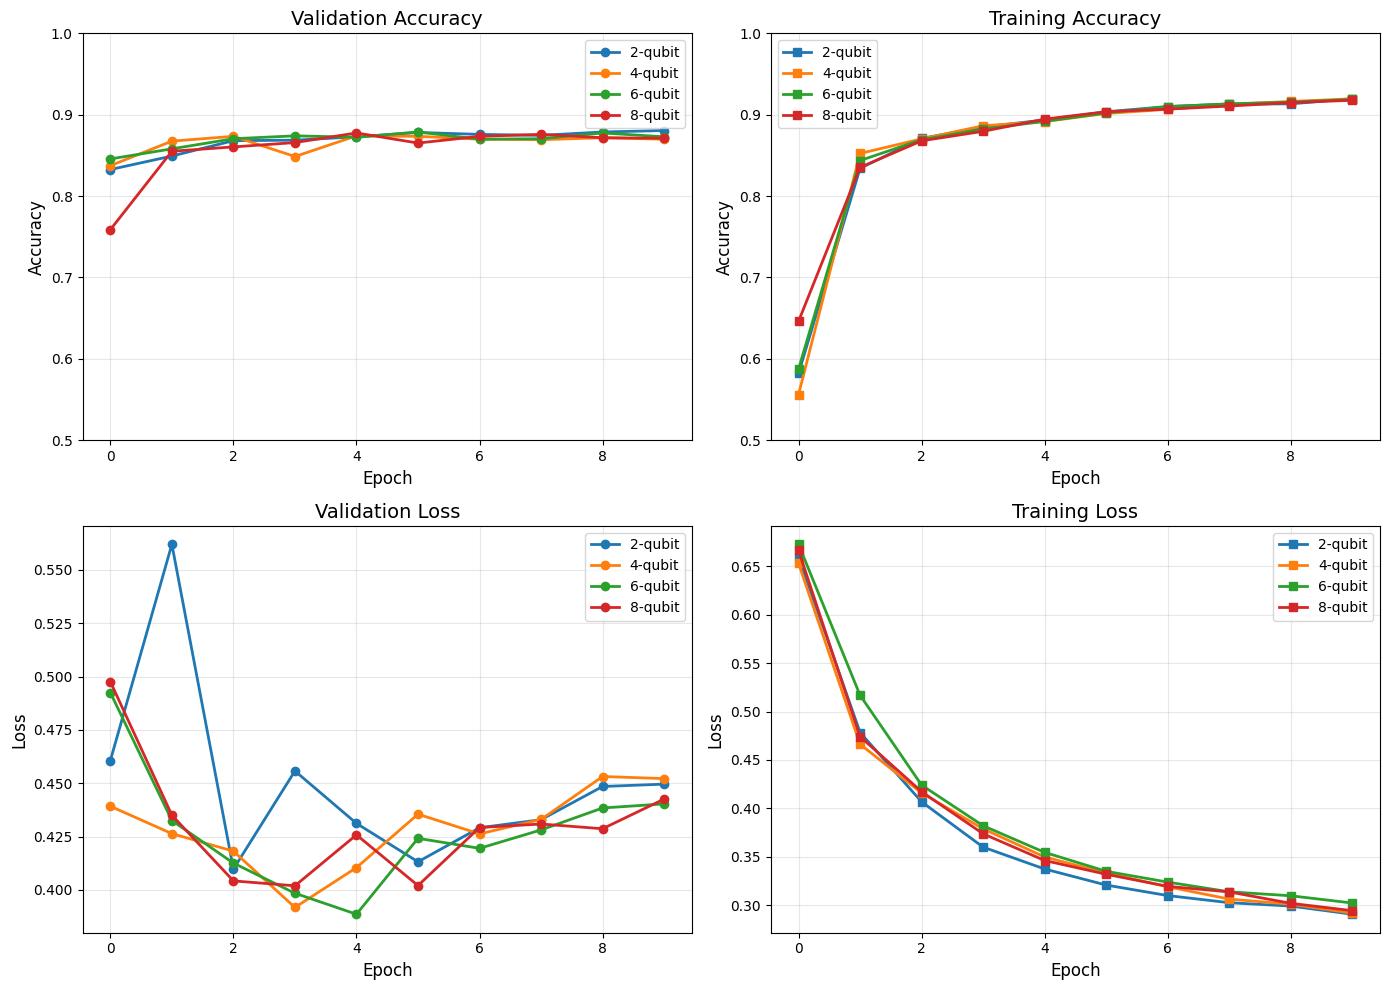

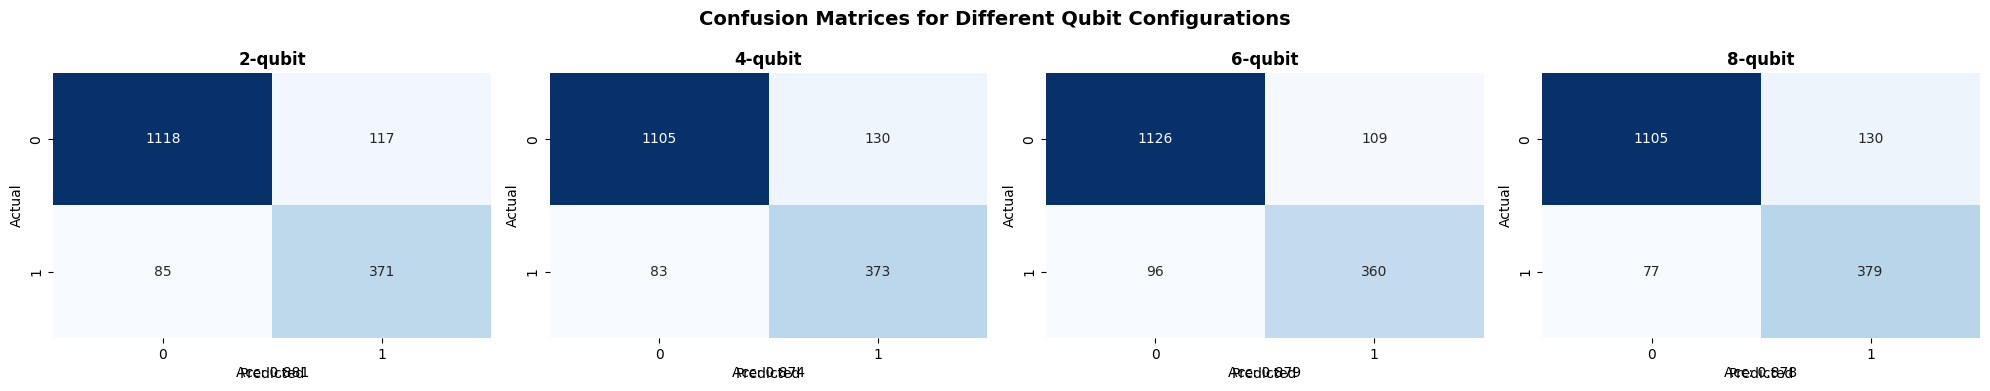

 Confusion matrices saved to mpqa_qubit_confusion_matrices.pdf


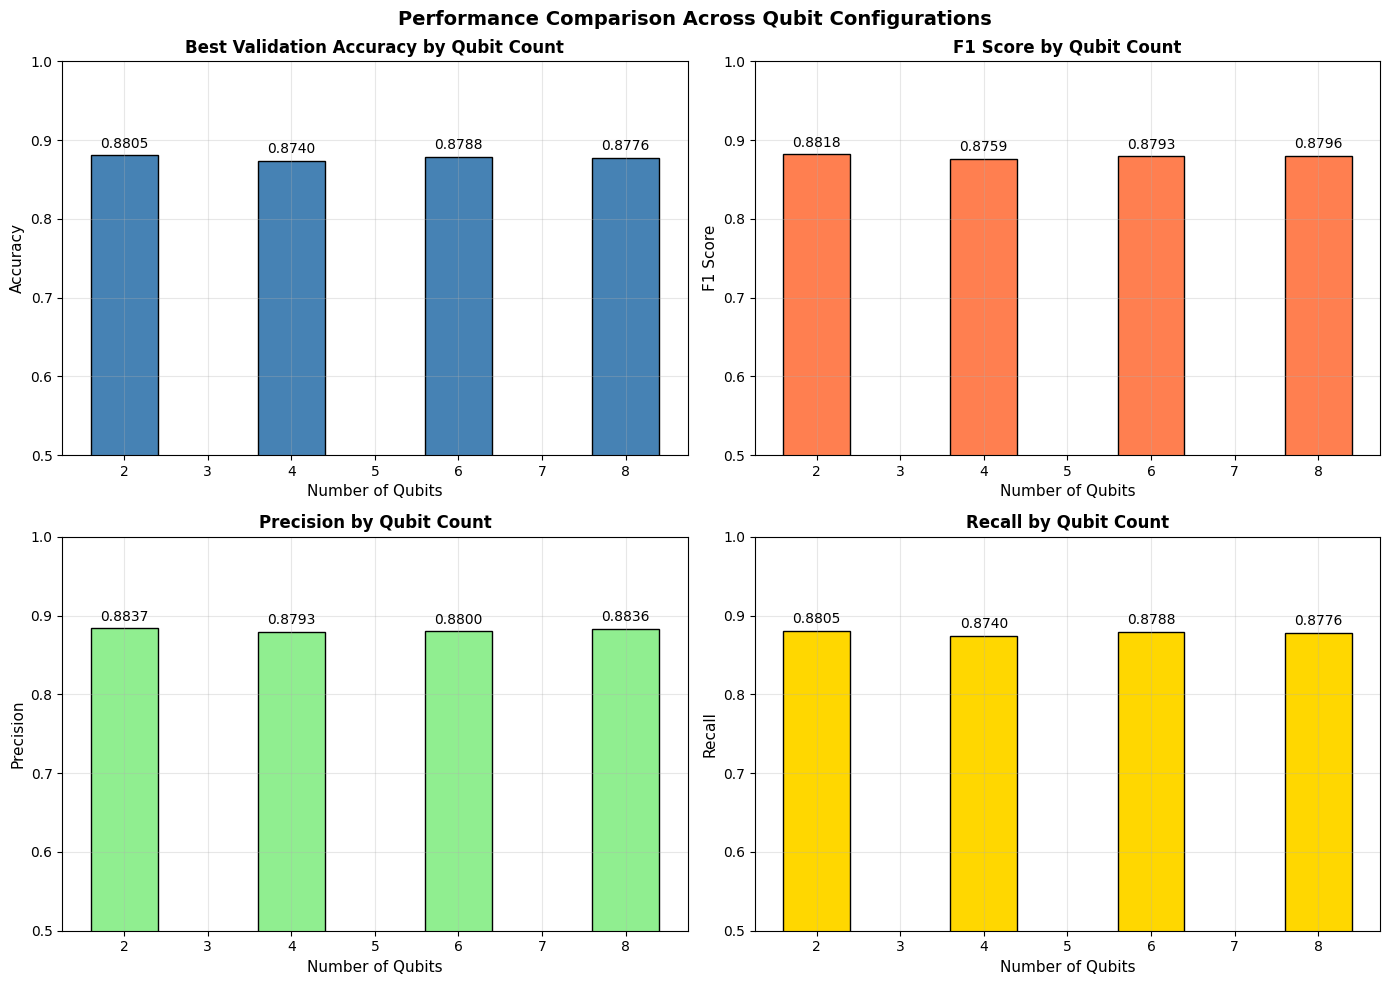

 Performance comparison chart saved to mpqa_qubit_performance_comparison.pdf


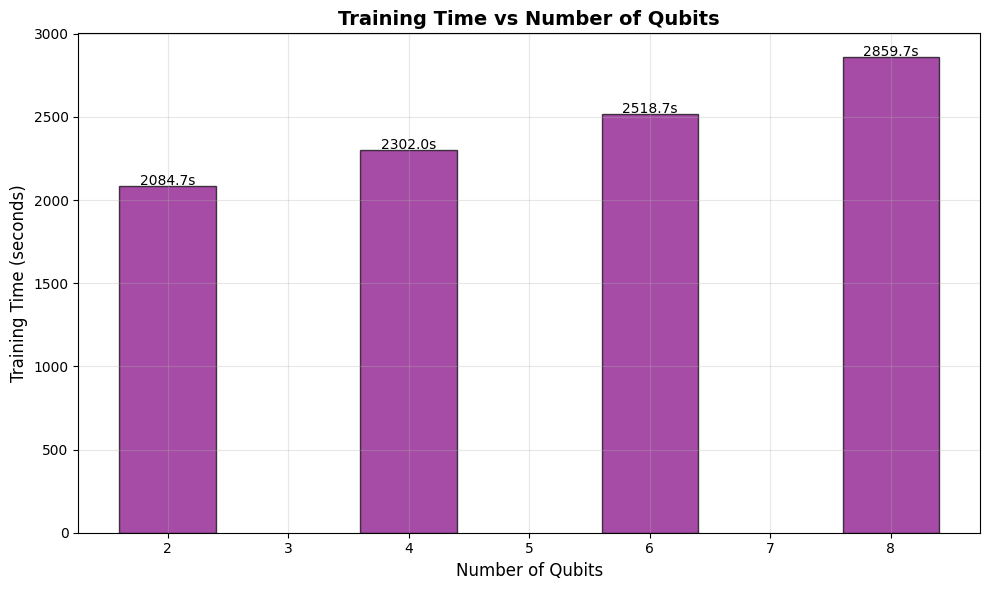

 Training time comparison saved to mpqa_qubit_training_time.pdf

QUANTUM CIRCUIT ARCHITECTURES FOR DIFFERENT QUBIT COUNTS

2-Qubit Circuit Diagram:
   ┌──────────┐     ┌──────────┐
0: ┤ Hadamard ├─────┤ RX(θ0)  ├─┐
   └──────────┘     └──────────┘ │
   ┌──────────┐     ┌──────────┐ │ ┌───┐ ┌──────────┐
1: ┤ Hadamard ├─────┤ RY(θ1)  ├─┼─┤ X ├─┤ RZ(ω0)  ├─► Z expectation
   └──────────┘     └──────────┘ │ └─┬─┘ └──────────┘
                                  │   │   ┌──────────┐
                                  └───┼───┤ RZ(ω1)  ├─► (not measured)
                                      │   └──────────┘
                                      └───┘

4-Qubit Circuit Diagram:
   4-qubit circuit with Hadamard gates, RX/RY encoding,
   ring entanglement, and trainable RZ rotations on all qubits.

6-Qubit Circuit Diagram:
   6-qubit circuit with Hadamard gates, RX/RY encoding,
   ring entanglement, and trainable RZ rotations on all qubits.

8-Qubit Circuit Diagram:
   8-qubit circuit with Hadamar

TypeError: sequence item 0: expected str instance, numpy.int64 found

In [4]:
# ============================================================
# RESULTS SUMMARY TABLE
# ============================================================


print("\n" + "="*80)
print("DETAILED RESULTS FOR ALL QUBIT CONFIGURATIONS")
print("="*80)
print(f"{'Qubits':<10} {'Best Val Acc':<14} {'Final Val Acc':<14} {'Train Acc':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Val Loss':<12} {'Time (s)':<10}")
print("-"*110)
for r in all_results:
    print(f"{r['n_qubits']:<10} {r['best_val_accuracy']:<14.4f} {r['final_val_accuracy']:<14.4f} {r['final_train_accuracy']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f} {r['f1_score']:<12.4f} {r['val_loss']:<12.4f} {r['training_time']:<10.2f}")

# Save results to CSV
results_df = pd.DataFrame([{
    'Qubits': r['n_qubits'],
    'Best Val Acc': r['best_val_accuracy'],
    'Final Val Acc': r['final_val_accuracy'],
    'Train Acc': r['final_train_accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Val Loss': r['val_loss'],
    'Training Time (s)': r['training_time']
} for r in all_results])
results_df.to_csv('mpqa_multi_qubit_results.csv', index=False)
print(f"\n Results saved to mpqa_multi_qubit_results.csv")

# ============================================================
# PLOT TRAINING CURVES FOR EACH QUBIT CONFIGURATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation accuracy
ax = axes[0, 0]
for r in all_results:
    ax.plot(r["val_accuracies"], marker="o", label=f"{r['n_qubits']}-qubit", linewidth=2)
ax.set_title("Validation Accuracy", fontsize=14)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Training accuracy
ax = axes[0, 1]
for r in all_results:
    ax.plot(r["train_accuracies"], marker="s", label=f"{r['n_qubits']}-qubit", linewidth=2)
ax.set_title("Training Accuracy", fontsize=14)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Validation loss
ax = axes[1, 0]
for r in all_results:
    ax.plot(r["val_losses"], marker="o", label=f"{r['n_qubits']}-qubit", linewidth=2)
ax.set_title("Validation Loss", fontsize=14)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Training loss
ax = axes[1, 1]
for r in all_results:
    ax.plot(r["train_losses"], marker="s", label=f"{r['n_qubits']}-qubit", linewidth=2)
ax.set_title("Training Loss", fontsize=14)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mpqa_qubit_training_curves.pdf", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# CONFUSION MATRICES FOR EACH QUBIT CONFIGURATION
# ============================================================

num_configs = len(all_results)
fig, axes = plt.subplots(1, num_configs, figsize=(5*num_configs, 4))
if num_configs == 1:
    axes = [axes]

for idx, r in enumerate(all_results):
    cm = r["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues', cbar=False)
    axes[idx].set_title(f"{r['n_qubits']}-qubit", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    
    # Add accuracy text
    axes[idx].text(0.5, -0.15, f"Acc: {r['best_val_accuracy']:.3f}", 
                   transform=axes[idx].transAxes, ha='center', fontsize=10)

plt.suptitle("Confusion Matrices for Different Qubit Configurations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("mpqa_qubit_confusion_matrices.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrices saved to mpqa_qubit_confusion_matrices.pdf")

# ============================================================
# PERFORMANCE COMPARISON BAR CHART
# ============================================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
qubits = [r['n_qubits'] for r in all_results]
accuracies = [r['best_val_accuracy'] for r in all_results]
bars1 = ax1.bar(qubits, accuracies, color='steelblue', edgecolor='black')
ax1.set_title('Best Validation Accuracy by Qubit Count', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Qubits', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_ylim([0.5, 1.0])
ax1.grid(True, alpha=0.3)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}', ha='center', fontsize=10)

# F1 Score comparison
f1_scores = [r['f1_score'] for r in all_results]
bars2 = ax2.bar(qubits, f1_scores, color='coral', edgecolor='black')
ax2.set_title('F1 Score by Qubit Count', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Qubits', fontsize=11)
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_ylim([0.5, 1.0])
ax2.grid(True, alpha=0.3)
for bar, f1 in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{f1:.4f}', ha='center', fontsize=10)

# Precision comparison
precisions = [r['precision'] for r in all_results]
bars3 = ax3.bar(qubits, precisions, color='lightgreen', edgecolor='black')
ax3.set_title('Precision by Qubit Count', fontsize=12, fontweight='bold')
ax3.set_xlabel('Number of Qubits', fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_ylim([0.5, 1.0])
ax3.grid(True, alpha=0.3)
for bar, prec in zip(bars3, precisions):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{prec:.4f}', ha='center', fontsize=10)

# Recall comparison
recalls = [r['recall'] for r in all_results]
bars4 = ax4.bar(qubits, recalls, color='gold', edgecolor='black')
ax4.set_title('Recall by Qubit Count', fontsize=12, fontweight='bold')
ax4.set_xlabel('Number of Qubits', fontsize=11)
ax4.set_ylabel('Recall', fontsize=11)
ax4.set_ylim([0.5, 1.0])
ax4.grid(True, alpha=0.3)
for bar, rec in zip(bars4, recalls):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{rec:.4f}', ha='center', fontsize=10)

plt.suptitle('Performance Comparison Across Qubit Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("mpqa_qubit_performance_comparison.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" Performance comparison chart saved to mpqa_qubit_performance_comparison.pdf")

# ============================================================
# TRAINING TIME COMPARISON
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
times = [r['training_time'] for r in all_results]
bars = ax.bar(qubits, times, color='purple', edgecolor='black', alpha=0.7)
ax.set_title('Training Time vs Number of Qubits', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Qubits', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.grid(True, alpha=0.3)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            f'{t:.1f}s', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("mpqa_qubit_training_time.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" Training time comparison saved to mpqa_qubit_training_time.pdf")

# ============================================================
# QUANTUM CIRCUIT VISUALIZATION FOR EACH CONFIGURATION
# ============================================================

print("\n" + "="*80)
print("QUANTUM CIRCUIT ARCHITECTURES FOR DIFFERENT QUBIT COUNTS")
print("="*80)

for n_qubits in QUBIT_CONFIGS:
    print(f"\n{n_qubits}-Qubit Circuit Diagram:")
    if n_qubits == 2:
        print("   ┌──────────┐     ┌──────────┐")
        print("0: ┤ Hadamard ├─────┤ RX(θ0)  ├─┐")
        print("   └──────────┘     └──────────┘ │")
        print("   ┌──────────┐     ┌──────────┐ │ ┌───┐ ┌──────────┐")
        print("1: ┤ Hadamard ├─────┤ RY(θ1)  ├─┼─┤ X ├─┤ RZ(ω0)  ├─► Z expectation")
        print("   └──────────┘     └──────────┘ │ └─┬─┘ └──────────┘")
        print("                                  │   │   ┌──────────┐")
        print("                                  └───┼───┤ RZ(ω1)  ├─► (not measured)")
        print("                                      │   └──────────┘")
        print("                                      └───┘")
    else:
        print(f"   {n_qubits}-qubit circuit with Hadamard gates, RX/RY encoding,")
        print(f"   ring entanglement, and trainable RZ rotations on all qubits.")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*80)
print("FINAL SUMMARY REPORT - MPQA SENTIMENT ANALYSIS")
print("="*80)
print(f"Dataset: MPQA Opinion Corpus")
print(f"Total samples after preprocessing: {len(df)}")
print(f"Number of classes: {len(label_encoder.classes_)} ({', '.join(label_encoder.classes_)})")
print(f"Model Architecture: QBiLSTM-Q")
print(f"Base Encoder: {MODEL_NAME}")
print(f"Optimizer: AdamW")
print(f"Learning Rate: 2e-5")
print(f"Batch Size: 32")
print(f"Fixed Seed: {FIXED_SEED}")
print(f"Qubit Configurations Evaluated: {QUBIT_CONFIGS}")
print(f"\n Performance Summary:")

# Find best performing configuration
best_idx = np.argmax([r['best_val_accuracy'] for r in all_results])
best_config = all_results[best_idx]
print(f"\n Best Configuration: {best_config['n_qubits']}-qubit circuit")
print(f"   Best Validation Accuracy: {best_config['best_val_accuracy']:.4f}")
print(f"   F1-Score: {best_config['f1_score']:.4f}")
print(f"   Precision: {best_config['precision']:.4f}")
print(f"   Recall: {best_config['recall']:.4f}")

# Performance trends
print(f"\n📈 Performance Trends:")
for r in all_results:
    print(f"   {r['n_qubits']}-qubit: Acc={r['best_val_accuracy']:.4f}, F1={r['f1_score']:.4f}, Time={r['training_time']:.1f}s")

# Suggest optimal qubit count
optimal_qubits = best_config['n_qubits']
print(f"\n Recommendation: {optimal_qubits}-qubit circuit provides the best performance")
print("="*80)

print("\n All results, plots, and statistics generated successfully for multiple qubit configurations!")